In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import tensorflow as tf
import cv2
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.utils import image_dataset_from_directory
from sklearn import metrics
import os
import warnings
warnings.filterwarnings("ignore")

In [2]:
IMG_SHAPE = (128, 128)
BATCH_SIZE = 32

In [5]:
data = image_dataset_from_directory('MRI/Training',
                                    image_size= IMG_SHAPE,
                                    color_mode= 'rgb',
                                    batch_size= BATCH_SIZE,
                                    shuffle= True,
                                    seed = 2022
                                   )

Found 5600 files belonging to 4 classes.


In [6]:
test_data = image_dataset_from_directory('MRI/Testing',
                                    image_size= IMG_SHAPE,
                                    color_mode= 'rgb',
                                    batch_size= BATCH_SIZE,
                                    shuffle= True,
                                    seed = 2022
                                   )

Found 1600 files belonging to 4 classes.


In [7]:
print("Total number of batches: ",len(data))

Total number of batches:  175


In [8]:
class_names = data.class_names
for idx, name in enumerate(class_names):
  print(f"{idx} = {name}", end=", ")

0 = glioma, 1 = meningioma, 2 = notumor, 3 = pituitary, 

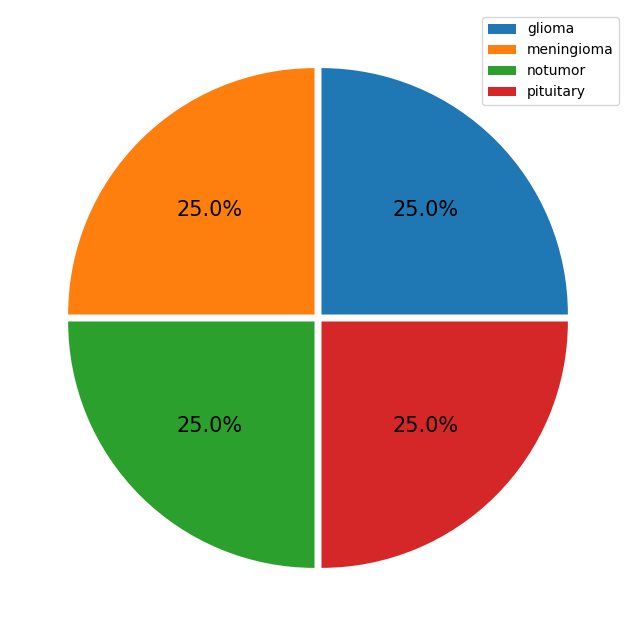

0    1400
1    1400
2    1400
3    1400
Name: count, dtype: int64


In [13]:
labels = np.concatenate([y for x,y in data], axis=0)
values = pd.Series(labels).value_counts()
values = values.sort_index()
plt.figure(figsize=(12,8))
plt.pie(values,autopct='%1.1f%%', explode = [0.02] * len(values), textprops = {"fontsize":15})
plt.legend(labels=data.class_names)
plt.show()
print(values)

In [15]:
data_iterator = data.as_numpy_iterator()
batch = data_iterator.next()
batch[0].shape


(32, 128, 128, 3)

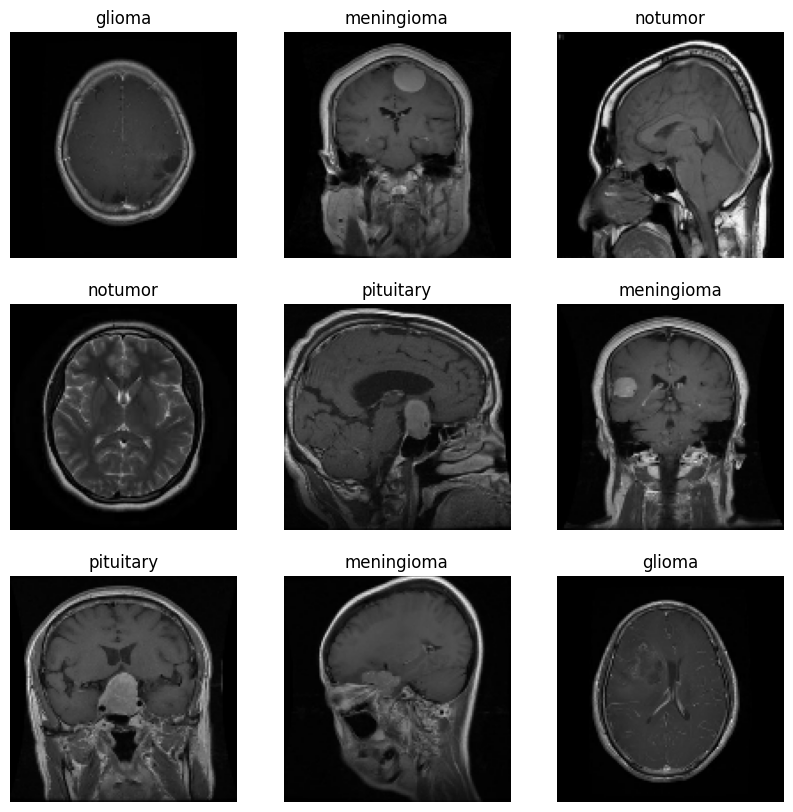

In [16]:
plt.figure(figsize=(10, 10))
for images, label in data.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[label[i]])
        plt.axis("off")

In [17]:
data = data.map(lambda x, y: (x/255., y))
sample = data.as_numpy_iterator().next()
print(sample[0].min())
print(sample[0].max())


0.0
1.0


In [18]:
train_size = int(0.80 * len(data)) 
val_size = int(0.20 * len(data))
train = data.take(train_size)
val = data.skip(train_size)

In [19]:
print(f"# train batchs = {len(train)}, # validate batchs = {len(val)}")
len(train) + len(val) 

# train batchs = 140, # validate batchs = 35


175